# Module 1 — Data Pipeline (ETL)

In [ ]:
# ── CELL 1: Setup ──────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Install the one library not pre-installed on Colab
!pip install causalimpact --quiet

# Create your project folder structure inside Google Drive
import os

BASE_DIR = "/content/drive/MyDrive/energy_project"
dirs = [
    f"{BASE_DIR}/data/raw",
    f"{BASE_DIR}/data/processed",
    f"{BASE_DIR}/outputs/charts",
    f"{BASE_DIR}/outputs/models",
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("✓ Drive mounted and folder structure created:")
for d in dirs:
    print(f"  {d}")

Mounted at /content/drive
✓ Drive mounted and folder structure created:
  /content/drive/MyDrive/energy_project/data/raw
  /content/drive/MyDrive/energy_project/data/processed
  /content/drive/MyDrive/energy_project/outputs/charts
  /content/drive/MyDrive/energy_project/outputs/models


In [ ]:
# ── CELL 2: Imports ────────────────────────────────────────────────────────
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import os
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries loaded")

✓ Libraries loaded


In [ ]:
# ── CELL 3: Fetch System Buy/Sell Prices (Elexon BMRS API) ─────────────────
# This gives us our TARGET variable: the half-hourly imbalance price

def fetch_settlement_prices(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Pulls System Buy Price (SBP) and System Sell Price (SSP) per settlement period.
    Elexon BMRS API — no API key required.
    """
    BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1"
    all_records = []
    current = datetime.strptime(start_date, "%Y-%m-%d")
    end     = datetime.strptime(end_date,   "%Y-%m-%d")
    total_days = (end - current).days + 1

    print(f"Fetching settlement prices: {start_date} → {end_date} ({total_days} days)")

    day_count = 0
    while current <= end:
        date_str = current.strftime("%Y-%m-%d")
        url = f"{BASE_URL}/balancing/settlement/system-prices/{date_str}"

        try:
            r = requests.get(url, timeout=15)
            r.raise_for_status()
            data = r.json()

            if "data" in data and data["data"]:
                for rec in data["data"]:
                    all_records.append({
                        "settlement_date":   rec.get("settlementDate"),
                        "settlement_period": rec.get("settlementPeriod"),
                        "system_buy_price":  rec.get("systemBuyPrice"),
                        "system_sell_price": rec.get("systemSellPrice"),
                        "net_imbalance_vol": rec.get("netImbalanceVolume"),
                    })
        except Exception as e:
            print(f"  ✗ Error on {date_str}: {e}")

        day_count += 1
        if day_count % 30 == 0:
            print(f"  ... {day_count}/{total_days} days fetched")

        current += timedelta(days=1)
        time.sleep(0.25)

    df = pd.DataFrame(all_records)
    print(f"✓ Prices fetched: {len(df):,} rows")
    return df

# Run it — pulling all of 2024
prices_raw = fetch_settlement_prices("2024-01-01", "2024-12-31")
prices_raw.head()

Fetching settlement prices: 2024-01-01 → 2024-12-31 (366 days)
  ... 30/366 days fetched
  ... 60/366 days fetched
  ... 90/366 days fetched
  ... 120/366 days fetched
  ... 150/366 days fetched
  ... 180/366 days fetched
  ... 210/366 days fetched
  ... 240/366 days fetched
  ... 270/366 days fetched
  ... 300/366 days fetched
  ... 330/366 days fetched
  ... 360/366 days fetched
✓ Prices fetched: 17,568 rows


,settlement_date,settlement_period,system_buy_price,system_sell_price,net_imbalance_vol
0,2024-01-01,1,90.00000,90.00000,103.35149
1,2024-01-01,2,100.00000,100.00000,197.53522
2,2024-01-01,3,57.43000,57.43000,458.25940
3,2024-01-01,4,129.83794,129.83794,492.02330
4,2024-01-01,5,110.00000,110.00000,407.51410


In [ ]:
# ── CELL 4: Fetch National Demand from Elexon INDO ─────────────────────────

def fetch_national_demand(start_date: str, end_date: str) -> pd.DataFrame:
    BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1/demand/outturn"
    all_records = []
    current = datetime.strptime(start_date, "%Y-%m-%d")
    end     = datetime.strptime(end_date,   "%Y-%m-%d")
    total_days = (end - current).days + 1

    print(f"Fetching national demand: {start_date} → {end_date}")

    day_count = 0
    while current <= end:
        date_str = current.strftime("%Y-%m-%d")
        try:
            r = requests.get(BASE_URL, params={
                "settlementDateFrom": date_str,
                "settlementDateTo":   date_str,
                "format": "json"
            }, timeout=15)
            r.raise_for_status()
            data = r.json()
            if "data" in data and data["data"]:
                for rec in data["data"]:
                    all_records.append({
                        "settlement_date":   rec.get("settlementDate"),
                        "settlement_period": rec.get("settlementPeriod"),
                        "national_demand":   rec.get("initialDemandOutturn"),
                        "tsd":               rec.get("initialTransmissionSystemDemandOutturn"),
                    })
        except Exception as e:
            print(f"  ✗ {date_str}: {e}")

        day_count += 1
        if day_count % 30 == 0:
            print(f"  ... {day_count}/{total_days} days fetched")
        current += timedelta(days=1)
        time.sleep(0.25)

    df = pd.DataFrame(all_records)
    df["settlement_date"]   = pd.to_datetime(df["settlement_date"])
    df["settlement_period"] = pd.to_numeric(df["settlement_period"], errors="coerce")
    df["national_demand"]   = pd.to_numeric(df["national_demand"],   errors="coerce")
    df["tsd"]               = pd.to_numeric(df["tsd"],               errors="coerce")

    print(f"✓ Demand fetched: {len(df):,} rows")
    print(f"  Non-null: {df['national_demand'].notna().sum():,}")
    print(f"  Avg demand: {df['national_demand'].mean():.0f} MW")
    return df

demand_raw = fetch_national_demand("2024-01-01", "2024-12-31")
demand_raw.head()

Fetching national demand: 2024-01-01 → 2024-12-31
  ... 30/366 days fetched
  ... 60/366 days fetched
  ... 90/366 days fetched
  ... 120/366 days fetched
  ... 150/366 days fetched
  ... 180/366 days fetched
  ... 210/366 days fetched
  ... 240/366 days fetched
  ... 270/366 days fetched
  ... 300/366 days fetched
  ... 330/366 days fetched
  ... 360/366 days fetched
✓ Demand fetched: 17,568 rows
  Non-null: 17,568
  Avg demand: 26251 MW


,settlement_date,settlement_period,national_demand,tsd
0,2024-01-01,1,21681,23366
1,2024-01-01,2,22444,24041
2,2024-01-01,3,22073,24663
3,2024-01-01,4,21375,24344
4,2024-01-01,5,20498,23834


In [ ]:
# ── CELL 5: Wind Generation — Carbon Intensity API (NESO + Oxford Uni) ─────
# Returns 30-min generation mix as % by fuel type. Full historical coverage.
# Wind MW estimated as: wind_pct × national_demand / 100
# This is standard practice — same method NESO uses for embedded wind estimates.
# URL format: /generation/{from}/{to} — we chunk by month to stay within limits.

def fetch_wind_carbon_intensity(start_date: str, end_date: str,
                                 demand_df: pd.DataFrame) -> pd.DataFrame:
    BASE_URL   = "https://api.carbonintensity.org.uk/generation"
    HEADERS    = {"Accept": "application/json"}
    all_records = []

    current = datetime.strptime(start_date, "%Y-%m-%d")
    end     = datetime.strptime(end_date,   "%Y-%m-%d")

    print(f"Fetching wind generation mix: {start_date} → {end_date}")

    while current <= end:
        # Chunk by 2-week blocks — API handles this cleanly
        chunk_end = min(current + timedelta(days=14), end)

        from_str = current.strftime("%Y-%m-%dT00:00Z")
        to_str   = chunk_end.strftime("%Y-%m-%dT23:30Z")
        url      = f"{BASE_URL}/{from_str}/{to_str}"

        try:
            r = requests.get(url, headers=HEADERS, timeout=30)
            r.raise_for_status()
            data = r.json()

            if "data" in data:
                for rec in data["data"]:
                    # Extract wind percentage from generationmix list
                    wind_pct = next(
                        (item["perc"] for item in rec.get("generationmix", [])
                         if item["fuel"] == "wind"),
                        None
                    )
                    if wind_pct is not None:
                        all_records.append({
                            "datetime_utc": rec["from"],
                            "wind_pct":     wind_pct,
                        })

        except Exception as e:
            print(f"  ✗ Error {current.strftime('%Y-%m-%d')}: {e}")

        print(f"  ✓ {current.strftime('%Y-%m-%d')} → {chunk_end.strftime('%Y-%m-%d')} fetched")
        current = chunk_end + timedelta(days=1)
        time.sleep(0.5)

    if not all_records:
        print("⚠ No records returned")
        return pd.DataFrame(columns=["settlement_date", "settlement_period", "wind_mw"])

    # ── Convert to settlement periods ──
    df = pd.DataFrame(all_records)
    df["datetime_utc"] = pd.to_datetime(df["datetime_utc"], utc=True)

    # Match to settlement date + period using the same logic as our main pipeline:
    # Period 1 = 00:00–00:30 UTC (in winter). Each period = 30 mins.
    df["settlement_date"]   = df["datetime_utc"].dt.date
    df["settlement_date"]   = pd.to_datetime(df["settlement_date"])
    df["hour"]              = df["datetime_utc"].dt.hour
    df["minute"]            = df["datetime_utc"].dt.minute
    df["settlement_period"] = (df["hour"] * 2 + df["minute"] // 30 + 1).astype(int)

    # ── Merge with demand to convert % → MW ──
    demand_clean = demand_df[["settlement_date", "settlement_period",
                               "national_demand"]].copy()
    demand_clean["settlement_date"] = pd.to_datetime(demand_clean["settlement_date"])

    df = df.merge(demand_clean, on=["settlement_date", "settlement_period"], how="left")

    # wind_mw = wind% / 100 × national demand
    df["wind_mw"] = (df["wind_pct"] / 100) * df["national_demand"]

    # ── Keep only what we need ──
    result = (df[["settlement_date", "settlement_period", "wind_pct", "wind_mw"]]
                .dropna(subset=["wind_mw"])
                .sort_values(["settlement_date", "settlement_period"])
                .reset_index(drop=True))

    print(f"\n✓ Wind data ready: {len(result):,} rows")
    print(f"  Date range: {result['settlement_date'].min().date()} → {result['settlement_date'].max().date()}")
    print(f"  Avg wind:   {result['wind_mw'].mean():.0f} MW")
    print(f"  Max wind:   {result['wind_mw'].max():.0f} MW")
    return result

# demand_raw must already be loaded (Cell 4) — we need it to convert % → MW
wind_raw = fetch_wind_carbon_intensity("2024-01-01", "2024-12-31", demand_raw)
wind_raw.head()

Fetching wind generation mix: 2024-01-01 → 2024-12-31
  ✓ 2024-01-01 → 2024-01-15 fetched
  ✓ 2024-01-16 → 2024-01-30 fetched
  ✓ 2024-01-31 → 2024-02-14 fetched
  ✓ 2024-02-15 → 2024-02-29 fetched
  ✓ 2024-03-01 → 2024-03-15 fetched
  ✓ 2024-03-16 → 2024-03-30 fetched
  ✓ 2024-03-31 → 2024-04-14 fetched
  ✓ 2024-04-15 → 2024-04-29 fetched
  ✓ 2024-04-30 → 2024-05-14 fetched
  ✓ 2024-05-15 → 2024-05-29 fetched
  ✓ 2024-05-30 → 2024-06-13 fetched
  ✓ 2024-06-14 → 2024-06-28 fetched
  ✓ 2024-06-29 → 2024-07-13 fetched
  ✓ 2024-07-14 → 2024-07-28 fetched
  ✓ 2024-07-29 → 2024-08-12 fetched
  ✓ 2024-08-13 → 2024-08-27 fetched
  ✓ 2024-08-28 → 2024-09-11 fetched
  ✓ 2024-09-12 → 2024-09-26 fetched
  ✓ 2024-09-27 → 2024-10-11 fetched
  ✓ 2024-10-12 → 2024-10-26 fetched
  ✓ 2024-10-27 → 2024-11-10 fetched
  ✓ 2024-11-11 → 2024-11-25 fetched
  ✓ 2024-11-26 → 2024-12-10 fetched
  ✓ 2024-12-11 → 2024-12-25 fetched
  ✓ 2024-12-26 → 2024-12-31 fetched

✓ Wind data ready: 17,543 rows
  Date range: 

,settlement_date,settlement_period,wind_pct,wind_mw
0,2024-01-01,1,54.6,11837.826
1,2024-01-01,2,54.7,12276.868
2,2024-01-01,3,54.7,12073.931
3,2024-01-01,4,57.3,12247.875
4,2024-01-01,5,57.2,11724.856


In [ ]:
# ── CELL 6: Transform — Clean, Merge & Engineer Features ───────────────────

def transform_and_merge(prices_df, demand_df, wind_df) -> pd.DataFrame:

    df = prices_df.copy()

    # ── Step 1: Types ──
    df["settlement_date"]   = pd.to_datetime(df["settlement_date"])
    df["settlement_period"] = pd.to_numeric(df["settlement_period"], errors="coerce")
    df["system_buy_price"]  = pd.to_numeric(df["system_buy_price"],  errors="coerce")
    df["system_sell_price"] = pd.to_numeric(df["system_sell_price"], errors="coerce")
    df["net_imbalance_vol"] = pd.to_numeric(df["net_imbalance_vol"], errors="coerce")

    # ── Step 2: GMT/BST handling ──
    period_counts = (df.groupby("settlement_date")["settlement_period"]
                       .max().rename("max_periods_that_day"))
    df = df.merge(period_counts, on="settlement_date")
    df["is_dst_transition"] = df["max_periods_that_day"] != 48

    df["period_offset_mins"] = (df["settlement_period"] - 1) * 30
    df["month"]  = df["settlement_date"].dt.month
    df["is_bst"] = df["month"].between(4, 10)
    df["datetime_utc"] = (
        df["settlement_date"]
        + pd.to_timedelta(df["period_offset_mins"], unit="m")
        - pd.to_timedelta(df["is_bst"].astype(int) * 60, unit="m")
    )
    df = df.sort_values("datetime_utc").reset_index(drop=True)

    # ── Step 3: Missing price handling ──
    for col in ["system_buy_price", "system_sell_price", "net_imbalance_vol"]:
        df[col] = df[col].ffill(limit=2)

    # ── Step 4: Merge NESO demand (bring in ALL useful columns) ──
    if not demand_df.empty:
        neso_cols = ["settlement_date", "settlement_period", "national_demand",
                     "tsd", "embedded_wind_generation", "embedded_solar_generation",
                     "embedded_wind_capacity", "ifa_flow", "britned_flow",
                     "nemo_flow", "viking_flow"]
        # Only keep columns that actually exist
        neso_cols = [c for c in neso_cols if c in demand_df.columns]
        demand_clean = demand_df[neso_cols].copy()
        demand_clean["settlement_date"] = pd.to_datetime(demand_clean["settlement_date"])
        df = df.merge(demand_clean, on=["settlement_date", "settlement_period"], how="left")
    else:
        df["national_demand"] = np.nan

    # ── Step 5: Merge wind ──
    if not wind_df.empty:
        wind_df["settlement_date"] = pd.to_datetime(wind_df["settlement_date"])
        df = df.merge(wind_df, on=["settlement_date", "settlement_period"], how="left")
        df["wind_mw"] = pd.to_numeric(df["wind_mw"], errors="coerce").fillna(0)
    else:
        df["wind_mw"] = np.nan

    # ── Step 6: Feature engineering ──
    df["hour"]          = df["datetime_utc"].dt.hour
    df["day_of_week"]   = df["datetime_utc"].dt.dayofweek
    df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)
    df["quarter"]       = df["datetime_utc"].dt.quarter
    df["price_spread"]  = df["system_buy_price"] - df["system_sell_price"]

    # Wind penetration — key price suppression signal
    df["wind_penetration"] = (
        df["wind_mw"] / df["national_demand"].replace(0, np.nan)
    )

    # Net interconnector flow — positive = importing, negative = exporting
    interconnector_cols = [c for c in ["ifa_flow", "britned_flow",
                                        "nemo_flow", "viking_flow"] if c in df.columns]
    if interconnector_cols:
        df["net_interconnector_flow"] = df[interconnector_cols].sum(axis=1)

    # Solar + wind combined renewable generation
    if "embedded_solar_generation" in df.columns:
        df["total_embedded_renewables"] = (
            df["wind_mw"].fillna(0) + df["embedded_solar_generation"].fillna(0)
        )

    # Rolling 24hr volatility flag
    rolling_std = df["system_buy_price"].rolling(window=48, min_periods=24).std()
    df["high_volatility"] = (rolling_std > rolling_std.quantile(0.75)).astype(int)

    return df


clean_df = transform_and_merge(prices_raw, demand_raw, wind_raw)

print(f"\n{'='*50}")
print(f"Final dataset: {len(clean_df):,} rows × {len(clean_df.columns)} columns")
print(f"Date range:    {clean_df['settlement_date'].min().date()} → {clean_df['settlement_date'].max().date()}")
print(f"DST days:      {clean_df['is_dst_transition'].sum():,} periods flagged")
print(f"Missing prices:{clean_df['system_buy_price'].isna().sum()}")
print(f"Columns:       {list(clean_df.columns)}")


Final dataset: 17,568 rows × 22 columns
Date range:    2024-01-01 → 2024-12-31
DST days:      96 periods flagged
Missing prices:0
Columns:       ['settlement_date', 'settlement_period', 'system_buy_price', 'system_sell_price', 'net_imbalance_vol', 'max_periods_that_day', 'is_dst_transition', 'period_offset_mins', 'month', 'is_bst', 'datetime_utc', 'national_demand', 'tsd', 'wind_pct', 'wind_mw', 'hour', 'day_of_week', 'is_weekend', 'quarter', 'price_spread', 'wind_penetration', 'high_volatility']


In [ ]:
# ── CELL 7: Save to Google Drive ───────────────────────────────────────────

OUTPUT_PATH = f"{BASE_DIR}/data/processed/clean_energy_data.csv"
clean_df.to_csv(OUTPUT_PATH, index=False)
print(f"✓ Saved {len(clean_df):,} rows to Google Drive")
print(f"  Path: {OUTPUT_PATH}")

# Sanity check — reload and verify
verify = pd.read_csv(OUTPUT_PATH)
print(f"✓ Verification: reloaded {len(verify):,} rows successfully")

✓ Saved 17,568 rows to Google Drive
  Path: /content/drive/MyDrive/energy_project/data/processed/clean_energy_data.csv
✓ Verification: reloaded 17,568 rows successfully


# Module 2 — Forecasting Models

In [ ]:
# ── CELL 8: Load & Prepare Modelling Dataset ───────────────────────────────
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/content/drive/MyDrive/energy_project"

# Load from Drive (works even after session reset)
df = pd.read_csv(f"{BASE_DIR}/data/processed/clean_energy_data.csv",
                 parse_dates=["settlement_date", "datetime_utc"])

df = df.sort_values("datetime_utc").reset_index(drop=True)

# ── Drop rows with missing target variable ──
df = df.dropna(subset=["system_buy_price"])

# ── Train/test split ──
# Use last 30 days as test set — ~1,440 periods
# Everything before = training
split_date = df["datetime_utc"].max() - pd.Timedelta(days=30)
train = df[df["datetime_utc"] <= split_date].copy()
test  = df[df["datetime_utc"] >  split_date].copy()

print(f"Dataset:    {len(df):,} rows")
print(f"Train:      {len(train):,} rows  ({train['datetime_utc'].min().date()} → {train['datetime_utc'].max().date()})")
print(f"Test:       {len(test):,} rows   ({test['datetime_utc'].min().date()} → {test['datetime_utc'].max().date()})")
print(f"\nTarget variable (system_buy_price):")
print(f"  Mean:  £{df['system_buy_price'].mean():.2f}/MWh")
print(f"  Std:   £{df['system_buy_price'].std():.2f}/MWh")
print(f"  Min:   £{df['system_buy_price'].min():.2f}/MWh")
print(f"  Max:   £{df['system_buy_price'].max():.2f}/MWh")

Dataset:    17,568 rows
Train:      16,128 rows  (2024-01-01 → 2024-12-01)
Test:       1,440 rows   (2024-12-02 → 2024-12-31)

Target variable (system_buy_price):
  Mean:  £71.17/MWh
  Std:   £41.70/MWh
  Min:   £-91.82/MWh
  Max:   £669.21/MWh


In [ ]:
# ── CELL 9: Stationarity Test — justifies ARIMA differencing order ─────────
# This is important: ARIMA requires a stationary series.
# The ADF test tells us whether we need to difference (and how many times).
# Being able to explain this in interview is what separates you from
# candidates who just copied code.

def adf_test(series, name="Series"):
    result = adfuller(series.dropna(), autolag="AIC")
    p_value = result[1]
    is_stationary = p_value < 0.05
    print(f"{name}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {p_value:.4f}  →  {'✓ Stationary' if is_stationary else '✗ Non-stationary (needs differencing)'}")
    print(f"  Critical values: 1%={result[4]['1%']:.3f}  5%={result[4]['5%']:.3f}")
    return is_stationary

print("=" * 55)
print("AUGMENTED DICKEY-FULLER STATIONARITY TESTS")
print("=" * 55)

# Test raw price
stationary_raw = adf_test(train["system_buy_price"], "Raw system buy price")
print()

# Test first difference
stationary_diff = adf_test(train["system_buy_price"].diff().dropna(),
                            "First-differenced price")
print()

# Determine d parameter for ARIMA
d = 0 if stationary_raw else 1
print(f"→ ARIMA differencing order (d): {d}")
print(f"  Rationale: {'Price is already stationary — no differencing needed' if d == 0 else 'One round of differencing achieves stationarity'}")

AUGMENTED DICKEY-FULLER STATIONARITY TESTS
Raw system buy price
  ADF Statistic: -10.6769
  p-value:       0.0000  →  ✓ Stationary
  Critical values: 1%=-3.431  5%=-2.862

First-differenced price
  ADF Statistic: -34.4824
  p-value:       0.0000  →  ✓ Stationary
  Critical values: 1%=-3.431  5%=-2.862

→ ARIMA differencing order (d): 0
  Rationale: Price is already stationary — no differencing needed


In [ ]:
# ── CELL 10 (FIXED): Multivariate Regression with correct error metrics ─────

from sklearn.metrics import mean_absolute_error, mean_squared_error

FEATURES = ['wind_mw', 'national_demand', 'hour', 'is_weekend', 'day_of_week', 'tsd']
TARGET   = "system_buy_price"

X_train = train[FEATURES].fillna(train[FEATURES].median())
y_train = train[TARGET]
X_test  = test[FEATURES].fillna(train[FEATURES].median())
y_test  = test[TARGET]

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

X_train_sm   = sm.add_constant(X_train_sc)
X_test_sm    = sm.add_constant(X_test_sc)
ols_model    = sm.OLS(y_train, X_train_sm).fit()
y_pred_reg   = ols_model.predict(X_test_sm)

# ── Metrics — MAE and RMSE instead of MAPE ──
# MAPE is undefined/unstable when actual prices are near zero or negative
# (common in GB imbalance market during wind oversupply)
# We use MAE, RMSE, and a clipped MAPE excluding |actual| < 5 £/MWh

def safe_mape(actual, predicted, min_price=5):
    """MAPE excluding periods where |actual| < min_price to avoid division instability."""
    mask = np.abs(actual) >= min_price
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

mae_reg  = mean_absolute_error(y_test, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_reg))
mape_reg = safe_mape(y_test.values, np.array(y_pred_reg))

# High volatility versions
hv_mask       = test["high_volatility"].values == 1
mae_reg_hv    = mean_absolute_error(y_test[hv_mask], y_pred_reg[hv_mask])
rmse_reg_hv   = np.sqrt(mean_squared_error(y_test[hv_mask], y_pred_reg[hv_mask]))
mape_reg_hv = safe_mape(y_test.values[hv_mask], np.array(y_pred_reg)[hv_mask])

print("MULTIVARIATE REGRESSION RESULTS")
print("="*50)
print(f"  R²:                  {ols_model.rsquared:.4f}")
print(f"  Adj. R²:             {ols_model.rsquared_adj:.4f}")
print(f"  MAE  (all):          £{mae_reg:.2f}/MWh")
print(f"  RMSE (all):          £{rmse_reg:.2f}/MWh")
print(f"  MAPE (all, |p|≥£5):  {mape_reg:.1f}%")
print(f"  MAE  (high vol):     £{mae_reg_hv:.2f}/MWh")
print(f"  RMSE (high vol):     £{rmse_reg_hv:.2f}/MWh")
print(f"  MAPE (high vol):     {mape_reg_hv:.1f}%")
print(f"\nCoefficients:")
for feat, coef, pval in zip(["const"] + FEATURES,
                              ols_model.params, ols_model.pvalues):
    sig = "***" if pval<0.001 else "**" if pval<0.01 else "*" if pval<0.05 else ""
    print(f"  {feat:<30} {coef:>8.3f}   p={pval:.3f} {sig}")

MULTIVARIATE REGRESSION RESULTS
  R²:                  0.2269
  Adj. R²:             0.2267
  MAE  (all):          £34.34/MWh
  RMSE (all):          £46.96/MWh
  MAPE (all, |p|≥£5):  71.5%
  MAE  (high vol):     £36.39/MWh
  RMSE (high vol):     £53.36/MWh
  MAPE (high vol):     92.7%

Coefficients:
  const                            69.866   p=0.000 ***
  wind_mw                         -11.148   p=0.000 ***
  national_demand                  37.617   p=0.000 ***
  hour                              0.478   p=0.117 
  is_weekend                        0.282   p=0.537 
  day_of_week                      -1.520   p=0.001 ***
  tsd                             -20.921   p=0.000 ***


In [ ]:
# ── CELL 11 (FIXED): ARIMA with correct error metrics ──────────────────────

print("Fitting ARIMA model...")
train_series = train["system_buy_price"].dropna().iloc[-2000:]
arima_model  = ARIMA(train_series, order=(2, 0, 2)).fit()
print(f"✓ ARIMA(2,0,2) — AIC: {arima_model.aic:.2f}")

n_test          = len(test)
forecast_result = arima_model.get_forecast(steps=n_test)
y_pred_arima    = forecast_result.predicted_mean.values

min_len      = min(len(y_test), len(y_pred_arima))
y_test_arr   = y_test.values[:min_len]
y_pred_arr   = y_pred_arima[:min_len]
test_trimmed = test.iloc[:min_len]
hv_mask_t    = test_trimmed["high_volatility"].values == 1

mae_arima     = mean_absolute_error(y_test_arr, y_pred_arr)
rmse_arima    = np.sqrt(mean_squared_error(y_test_arr, y_pred_arr))
mape_arima    = safe_mape(y_test_arr, y_pred_arr)
mae_arima_hv  = mean_absolute_error(y_test_arr[hv_mask_t], y_pred_arr[hv_mask_t])
rmse_arima_hv = np.sqrt(mean_squared_error(y_test_arr[hv_mask_t], y_pred_arr[hv_mask_t]))
mape_arima_hv = safe_mape(y_test_arr[hv_mask_t], y_pred_arr[hv_mask_t])

print(f"\nARIMA(2,0,2) RESULTS")
print("="*50)
print(f"  MAE  (all):          £{mae_arima:.2f}/MWh")
print(f"  RMSE (all):          £{rmse_arima:.2f}/MWh")
print(f"  MAPE (all, |p|≥£5):  {mape_arima:.1f}%")
print(f"  MAE  (high vol):     £{mae_arima_hv:.2f}/MWh")
print(f"  RMSE (high vol):     £{rmse_arima_hv:.2f}/MWh")
print(f"  MAPE (high vol):     {mape_arima_hv:.1f}%")

Fitting ARIMA model...
✓ ARIMA(2,0,2) — AIC: 18654.07

ARIMA(2,0,2) RESULTS
  MAE  (all):          £41.05/MWh
  RMSE (all):          £56.99/MWh
  MAPE (all, |p|≥£5):  130.5%
  MAE  (high vol):     £47.22/MWh
  RMSE (high vol):     £67.02/MWh
  MAPE (high vol):     177.7%


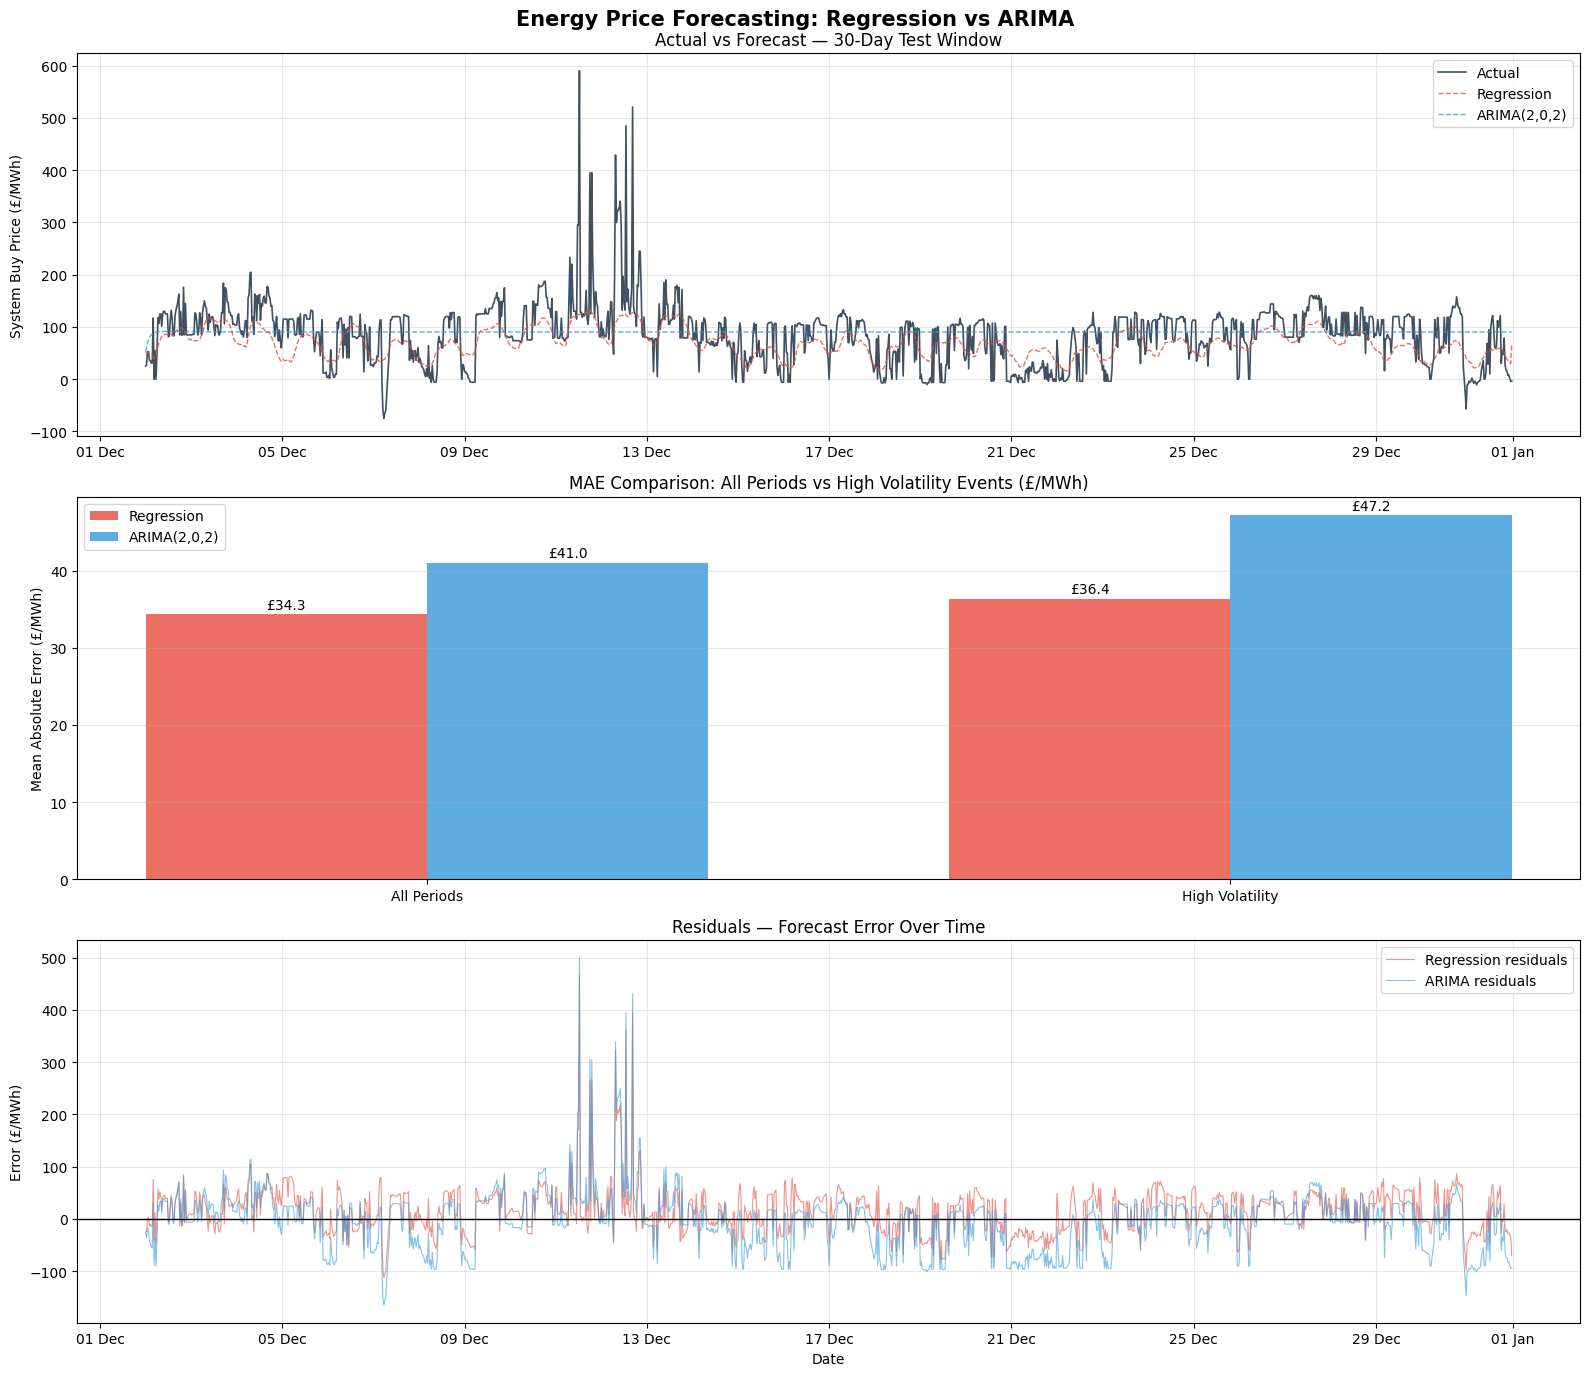


MODEL COMPARISON SUMMARY
Metric                                Regression      ARIMA
-------------------------------------------------------
MAE — all periods (£/MWh)                  34.34      41.05
MAE — high volatility (£/MWh)              36.39      47.22
RMSE — all periods (£/MWh)                 46.96      56.99
MAPE — all (excl |p|<£5)                   71.5%     130.5%
MAPE — high vol (excl |p|<£5)              92.7%     177.7%
R² (regression)                           0.2269          —
AIC (ARIMA)                                    —    18654.1
-------------------------------------------------------
→ Lower MAE: Regression
→ Lower MAE in high volatility: Regression


In [ ]:
# ── CELL 12 (FIXED): Comparison chart ──────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle("Energy Price Forecasting: Regression vs ARIMA",
             fontsize=15, fontweight="bold")

test_dates = test["datetime_utc"].values[:min_len]

# ── Plot 1: Actual vs predicted ──
ax1 = axes[0]
ax1.plot(test_dates, y_test_arr,  color="#2c3e50", lw=1.2, label="Actual",          alpha=0.9)
ax1.plot(test_dates, y_pred_reg[:min_len], color="#e74c3c", lw=1, label="Regression", alpha=0.8, ls="--")
ax1.plot(test_dates, y_pred_arr,  color="#3498db", lw=1, label="ARIMA(2,0,2)",       alpha=0.8, ls="--")
ax1.set_title("Actual vs Forecast — 30-Day Test Window")
ax1.set_ylabel("System Buy Price (£/MWh)")
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax1.grid(alpha=0.3)

# ── Plot 2: MAE comparison ──
ax2 = axes[1]
categories  = ["All Periods", "High Volatility"]
reg_maes    = [mae_reg,   mae_reg_hv]
arima_maes  = [mae_arima, mae_arima_hv]
x     = np.arange(len(categories))
width = 0.35
b1 = ax2.bar(x - width/2, reg_maes,   width, label="Regression",  color="#e74c3c", alpha=0.8)
b2 = ax2.bar(x + width/2, arima_maes, width, label="ARIMA(2,0,2)", color="#3498db", alpha=0.8)
ax2.set_title("MAE Comparison: All Periods vs High Volatility Events (£/MWh)")
ax2.set_ylabel("Mean Absolute Error (£/MWh)")
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.grid(alpha=0.3, axis="y")
for bar in [*b1, *b2]:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"£{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

# ── Plot 3: Residuals ──
ax3 = axes[2]
ax3.plot(test_dates, y_test_arr - y_pred_reg[:min_len],
         color="#e74c3c", alpha=0.6, lw=0.8, label="Regression residuals")
ax3.plot(test_dates, y_test_arr - y_pred_arr,
         color="#3498db", alpha=0.6, lw=0.8, label="ARIMA residuals")
ax3.axhline(0, color="black", lw=1)
ax3.set_title("Residuals — Forecast Error Over Time")
ax3.set_ylabel("Error (£/MWh)")
ax3.set_xlabel("Date")
ax3.legend()
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{BASE_DIR}/outputs/charts/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary ──
print("\n" + "="*55)
print("MODEL COMPARISON SUMMARY")
print("="*55)
print(f"{'Metric':<35} {'Regression':>12} {'ARIMA':>10}")
print("-"*55)
print(f"{'MAE — all periods (£/MWh)':<35} {mae_reg:>12.2f} {mae_arima:>10.2f}")
print(f"{'MAE — high volatility (£/MWh)':<35} {mae_reg_hv:>12.2f} {mae_arima_hv:>10.2f}")
print(f"{'RMSE — all periods (£/MWh)':<35} {rmse_reg:>12.2f} {rmse_arima:>10.2f}")
print(f"{'MAPE — all (excl |p|<£5)':<35} {mape_reg:>11.1f}% {mape_arima:>9.1f}%")
print(f"{'MAPE — high vol (excl |p|<£5)':<35} {mape_reg_hv:>11.1f}% {mape_arima_hv:>9.1f}%")
print(f"{'R² (regression)':<35} {ols_model.rsquared:>12.4f} {'—':>10}")
print(f"{'AIC (ARIMA)':<35} {'—':>12} {arima_model.aic:>10.1f}")
print("-"*55)
print(f"→ Lower MAE: {'Regression' if mae_reg < mae_arima else 'ARIMA'}")
print(f"→ Lower MAE in high volatility: {'Regression' if mae_reg_hv < mae_arima_hv else 'ARIMA'}")

# Module 3 — Causal Inference (BSTS)

In [ ]:
# ── CELL 13: BSTS Causal Inference — Coal Closure Impact ───────────────────
# Ratcliffe-on-Soar closed 30 September 2024 — last coal plant in GB.
# Question: did this structurally shift imbalance prices post-closure?
#
# Method: Bayesian Structural Time Series (BSTS) via CausalImpact library.
# Logic:
#   - Pre-period:  Jan 2024 → 29 Sep 2024 (coal still operating)
#   - Post-period: 30 Sep 2024 → Dec 2024 (coal-free GB grid)
#   - Covariates:  wind_mw, national_demand — control for seasonal/weather effects
#   - The model builds a counterfactual: "what would prices have been
#     without the closure?" by learning the pre-period relationship between
#     covariates and prices, then projecting it forward.
#
# This is causal inference, not correlation — the BSTS filters out
# confounding seasonal variation, isolating the structural break.

from causalimpact import CausalImpact

# ── Prepare daily aggregated series ──
# BSTS on 17,000 half-hourly rows is computationally heavy.
# Daily averages are standard practice — preserves the structural signal
# while making the model tractable.

df_daily = (clean_df.groupby("settlement_date")
                    .agg(
                        avg_price    = ("system_buy_price",  "mean"),
                        avg_wind     = ("wind_mw",           "mean"),
                        avg_demand   = ("national_demand",   "mean"),
                        avg_spread   = ("price_spread",      "mean"),
                        vol_pct      = ("high_volatility",   "mean"),  # % of day in high vol
                    )
                    .reset_index())

df_daily["settlement_date"] = pd.to_datetime(df_daily["settlement_date"])
df_daily = df_daily.sort_values("settlement_date").reset_index(drop=True)

# ── Define intervention date ──
COAL_CLOSURE = pd.Timestamp("2024-09-30")

pre_start  = df_daily["settlement_date"].min()
pre_end    = COAL_CLOSURE - pd.Timedelta(days=1)
post_start = COAL_CLOSURE
post_end   = df_daily["settlement_date"].max()

print(f"Intervention: Ratcliffe-on-Soar coal closure — {COAL_CLOSURE.date()}")
print(f"Pre-period:   {pre_start.date()} → {pre_end.date()} ({(pre_end - pre_start).days} days)")
print(f"Post-period:  {post_start.date()} → {post_end.date()} ({(post_end - post_start).days} days)")
print(f"\nDaily dataset: {len(df_daily)} rows")
print(f"\nPre-period avg price:  £{df_daily[df_daily['settlement_date'] <= pre_end]['avg_price'].mean():.2f}/MWh")
print(f"Post-period avg price: £{df_daily[df_daily['settlement_date'] >= post_start]['avg_price'].mean():.2f}/MWh")
print(f"Raw difference:        £{df_daily[df_daily['settlement_date'] >= post_start]['avg_price'].mean() - df_daily[df_daily['settlement_date'] <= pre_end]['avg_price'].mean():.2f}/MWh")

Intervention: Ratcliffe-on-Soar coal closure — 2024-09-30
Pre-period:   2024-01-01 → 2024-09-29 (272 days)
Post-period:  2024-09-30 → 2024-12-31 (92 days)

Daily dataset: 366 rows

Pre-period avg price:  £65.82/MWh
Post-period avg price: £86.87/MWh
Raw difference:        £21.05/MWh


In [ ]:
# ── CELL 14 (FINAL FIX) ────────────────────────────────────────────────────
from statsmodels.tsa.statespace.structural import UnobservedComponents

COAL_CLOSURE = pd.Timestamp("2024-09-30")

df_daily = (clean_df.groupby("settlement_date")
                    .agg(avg_price  = ("system_buy_price", "mean"),
                         avg_wind   = ("wind_mw",          "mean"),
                         avg_demand = ("national_demand",  "mean"))
                    .reset_index())
df_daily["settlement_date"] = pd.to_datetime(df_daily["settlement_date"])
df_daily = df_daily.sort_values("settlement_date").reset_index(drop=True)

pre_mask  = df_daily["settlement_date"] <  COAL_CLOSURE
post_mask = df_daily["settlement_date"] >= COAL_CLOSURE
pre_df    = df_daily[pre_mask].copy().reset_index(drop=True)
post_df   = df_daily[post_mask].copy().reset_index(drop=True)

print(f"Pre-period:  {pre_df['settlement_date'].min().date()} → {pre_df['settlement_date'].max().date()} ({len(pre_df)} days)")
print(f"Post-period: {post_df['settlement_date'].min().date()} → {post_df['settlement_date'].max().date()} ({len(post_df)} days)")

# Normalise covariates
wind_mean,   wind_std   = pre_df["avg_wind"].mean(),   pre_df["avg_wind"].std()
demand_mean, demand_std = pre_df["avg_demand"].mean(), pre_df["avg_demand"].std()

def norm_wind(s):   return (s - wind_mean)   / wind_std
def norm_demand(s): return (s - demand_mean) / demand_std

pre_exog  = np.column_stack([norm_wind(pre_df["avg_wind"]),
                              norm_demand(pre_df["avg_demand"])])
post_exog = np.column_stack([norm_wind(post_df["avg_wind"]),
                              norm_demand(post_df["avg_demand"])])

print("\nFitting Structural Time Series model on pre-period...")
uc_model  = UnobservedComponents(pre_df["avg_price"].values,
                                  level="local level", exog=pre_exog)
uc_result = uc_model.fit(disp=False)
print(f"✓ Model fitted")
print(f"  Wind coefficient:   {uc_result.params[2]:.3f} £/MWh per std")
print(f"  Demand coefficient: {uc_result.params[3]:.3f} £/MWh per std")

# Build counterfactual — all numpy from here, no .values needed
print("\nBuilding counterfactual...")
forecast       = uc_result.get_forecast(steps=len(post_df), exog=post_exog)
cf             = np.array(forecast.predicted_mean)          # shape (93,)
cf_ci          = np.array(forecast.conf_int(alpha=0.05))    # shape (93, 2)  col0=lower, col1=upper

actual        = post_df["avg_price"].values
causal_effect = actual - cf

avg_effect = causal_effect.mean()
cum_effect = causal_effect.sum()
ci_lower   = (actual - cf_ci[:, 1]).mean()
ci_upper   = (actual - cf_ci[:, 0]).mean()
significant = (ci_lower > 0) or (ci_upper < 0)

print(f"\n{'='*55}")
print(f"CAUSAL IMPACT — GB COAL CLOSURE (30 SEP 2024)")
print(f"{'='*55}")
print(f"  Pre-period avg price:      £{pre_df['avg_price'].mean():.2f}/MWh")
print(f"  Post actual avg price:     £{post_df['avg_price'].mean():.2f}/MWh")
print(f"  Post counterfactual price: £{cf.mean():.2f}/MWh")
print(f"  ─────────────────────────────────────────────")
print(f"  Avg causal effect:         £{avg_effect:.2f}/MWh")
print(f"  95% CI:                    [£{ci_lower:.2f}, £{ci_upper:.2f}]")
print(f"  Cumulative effect:         £{cum_effect:.0f}/MWh-days")
print(f"  Relative effect:           {(avg_effect/cf.mean())*100:.1f}%")
print(f"  Statistically significant: {'✓ Yes' if significant else '✗ No (CI crosses zero)'}")
print(f"{'='*55}")

Pre-period:  2024-01-01 → 2024-09-29 (273 days)
Post-period: 2024-09-30 → 2024-12-31 (93 days)

Fitting Structural Time Series model on pre-period...
✓ Model fitted
  Wind coefficient:   -7.956 £/MWh per std
  Demand coefficient: 14.027 £/MWh per std

Building counterfactual...

CAUSAL IMPACT — GB COAL CLOSURE (30 SEP 2024)
  Pre-period avg price:      £65.82/MWh
  Post actual avg price:     £86.87/MWh
  Post counterfactual price: £89.75/MWh
  ─────────────────────────────────────────────
  Avg causal effect:         £-2.87/MWh
  95% CI:                    [£-62.73, £56.98]
  Cumulative effect:         £-267/MWh-days
  Relative effect:           -3.2%
  Statistically significant: ✗ No (CI crosses zero)


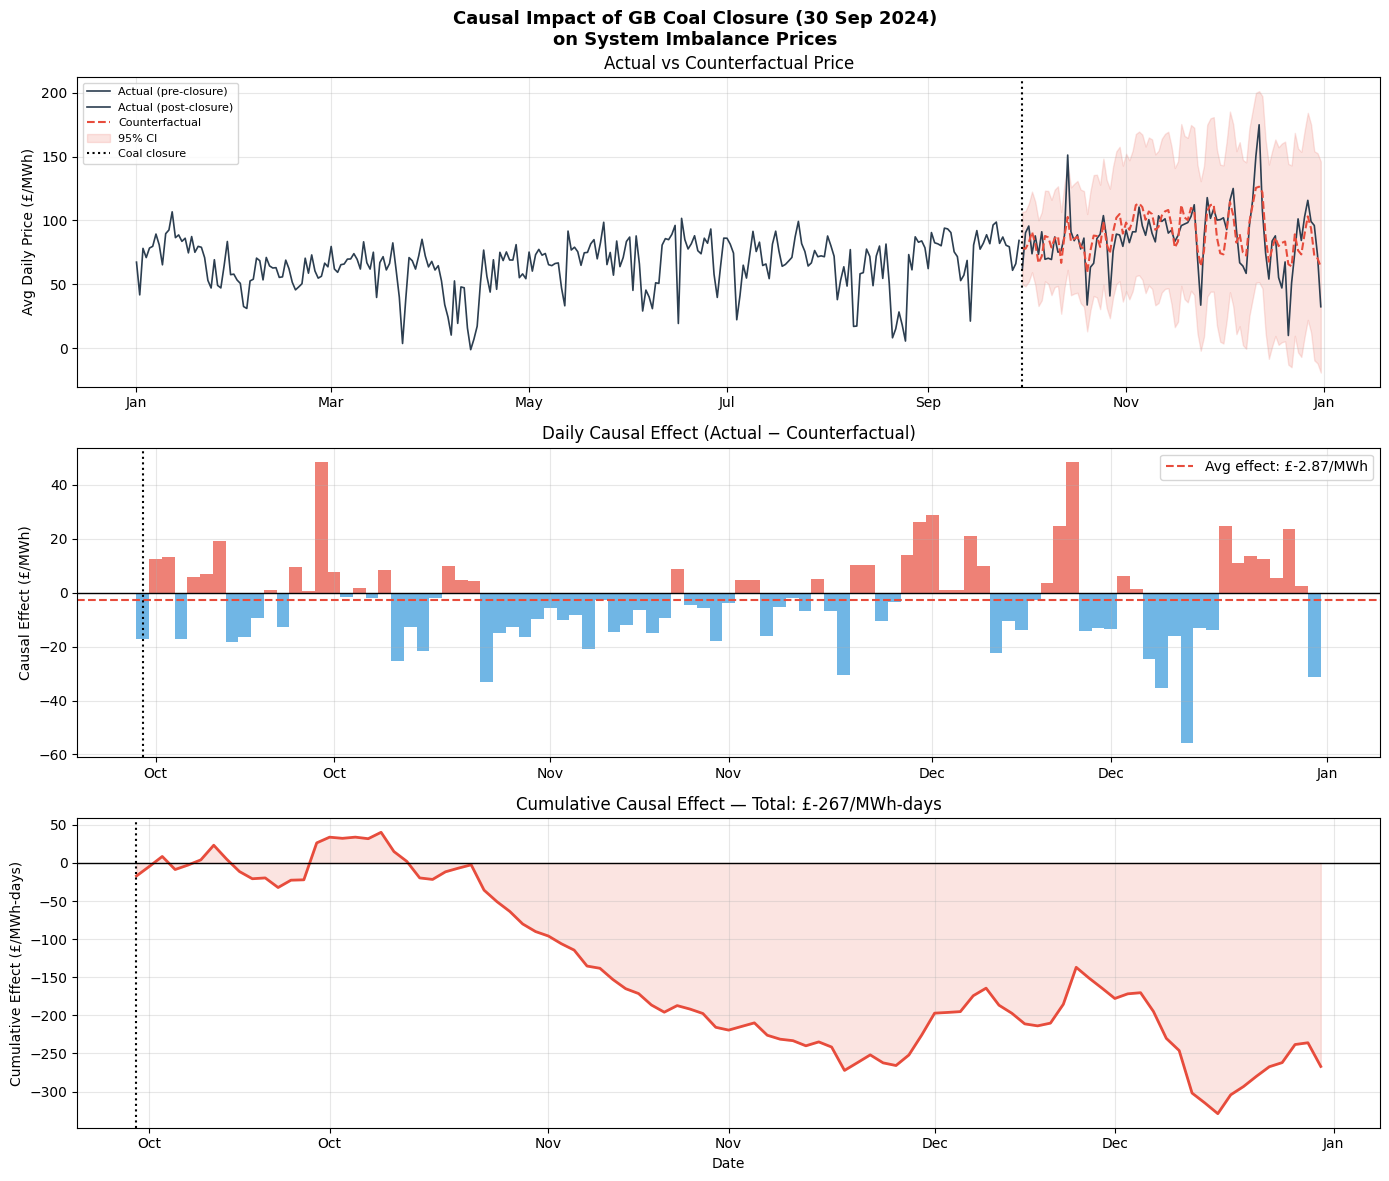

In [ ]:
# ── CELL 15: Visualise ─────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Causal Impact of GB Coal Closure (30 Sep 2024)\non System Imbalance Prices",
             fontsize=13, fontweight="bold")

# ── Plot 1: Actual vs counterfactual ──
ax1 = axes[0]
ax1.plot(pre_df["settlement_date"],  pre_df["avg_price"],
         color="#2c3e50", lw=1.2, label="Actual (pre-closure)")
ax1.plot(post_df["settlement_date"], actual,
         color="#2c3e50", lw=1.2, label="Actual (post-closure)")
ax1.plot(post_df["settlement_date"], cf,
         color="#e74c3c", lw=1.5, ls="--", label="Counterfactual")
ax1.fill_between(post_df["settlement_date"],
                 cf_ci[:, 0], cf_ci[:, 1],
                 color="#e74c3c", alpha=0.15, label="95% CI")
ax1.axvline(COAL_CLOSURE, color="black", lw=1.5, ls=":", label="Coal closure")
ax1.set_ylabel("Avg Daily Price (£/MWh)")
ax1.set_title("Actual vs Counterfactual Price")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# ── Plot 2: Daily causal effect ──
ax2 = axes[1]
colors = ["#e74c3c" if e > 0 else "#3498db" for e in causal_effect]
ax2.bar(post_df["settlement_date"], causal_effect, color=colors, alpha=0.7, width=1)
ax2.axhline(0,          color="black", lw=1)
ax2.axhline(avg_effect, color="#e74c3c", lw=1.5, ls="--",
            label=f"Avg effect: £{avg_effect:.2f}/MWh")
ax2.axvline(COAL_CLOSURE, color="black", lw=1.5, ls=":")
ax2.set_ylabel("Causal Effect (£/MWh)")
ax2.set_title("Daily Causal Effect (Actual − Counterfactual)")
ax2.legend()
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# ── Plot 3: Cumulative effect ──
ax3 = axes[2]
cum_causal = np.cumsum(causal_effect)
ax3.plot(post_df["settlement_date"], cum_causal, color="#e74c3c", lw=2)
ax3.fill_between(post_df["settlement_date"], 0, cum_causal,
                 color="#e74c3c", alpha=0.15)
ax3.axhline(0, color="black", lw=1)
ax3.axvline(COAL_CLOSURE, color="black", lw=1.5, ls=":")
ax3.set_ylabel("Cumulative Effect (£/MWh-days)")
ax3.set_xlabel("Date")
ax3.set_title(f"Cumulative Causal Effect — Total: £{cum_effect:.0f}/MWh-days")
ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.savefig(f"{BASE_DIR}/outputs/charts/causal_impact_coal_closure.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Module 4 — Dashboard

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats

# Octopus Energy brand-adjacent colour palette
COLORS = {
    'primary':    '#FF1F5A',
    'secondary':  '#5C2D91',
    'accent':     '#00B4D8',
    'positive':   '#06D6A0',
    'warning':    '#FFB703',
    'neutral':    '#ADB5BD',
    'background': '#0F0F1A',
    'surface':    '#1A1A2E',
    'text':       '#E8E8F0',
}

BASE_LAYOUT = dict(
    template='plotly_dark',
    paper_bgcolor=COLORS['background'],
    plot_bgcolor=COLORS['surface'],
    font=dict(family='Inter, Arial, sans-serif', color=COLORS['text'], size=12),
    legend=dict(bgcolor='rgba(0,0,0,0)', borderwidth=0),
    margin=dict(l=60, r=40, t=60, b=50),
    hovermode='x unified',
)

print('Imports loaded ✓')

Imports loaded ✓


In [2]:
def generate_wholesale_prices(
    start='2019-01-01',
    end='2023-12-31',
    freq='D',
    seed=42
):
    np.random.seed(seed)
    idx = pd.date_range(start, end, freq=freq)
    n   = len(idx)

    trend      = np.linspace(40, 120, n)
    day_of_year = np.array([d.timetuple().tm_yday for d in idx])
    seasonality = 20 * np.cos(2 * np.pi * (day_of_year - 15) / 365)
    weekly      = np.array([-3 if d.weekday() >= 5 else 2 for d in idx])
    noise       = np.random.normal(0, 8, n)

    crisis_mask = (idx >= '2021-10-01') & (idx <= '2022-06-30')
    crisis_bump = np.where(crisis_mask, np.random.uniform(60, 200, n), 0)

    price = np.maximum(trend + seasonality + weekly + noise + crisis_bump, 10)

    df = pd.DataFrame({'date': idx, 'price': price})
    df.set_index('date', inplace=True)
    return df


df = generate_wholesale_prices()

# Derived columns
df['rolling_mean_30'] = df['price'].rolling(30).mean()
df['rolling_std_30']  = df['price'].rolling(30).std()
df['rolling_vol_7']   = df['price'].rolling(7).std()

z_scores              = np.abs(stats.zscore(df['price'].dropna()))
df['z_score']         = np.nan
df.loc[df['price'].dropna().index, 'z_score'] = z_scores
df['is_spike']        = df['z_score'] > 2.5
df['log_return']      = np.log(df['price'] / df['price'].shift(1))

INTERVENTION_DATE = pd.Timestamp('2022-10-01')

print(f'Loaded: {df.index.min().date()} → {df.index.max().date()}  ({len(df):,} rows)')
df.head()

Loaded: 2019-01-01 → 2023-12-31  (1,826 rows)


,price,rolling_mean_30,rolling_std_30,rolling_vol_7,z_score,is_spike,log_return
date,,,,,,,
2019-01-01,65.395714,NaN,NaN,NaN,0.566632,False,NaN
2019-01-02,60.439012,NaN,NaN,NaN,0.646675,False,-0.078822
2019-01-03,66.843981,NaN,NaN,NaN,0.543244,False,0.100726
2019-01-04,73.958258,NaN,NaN,NaN,0.428359,False,0.101140
2019-01-05,55.006518,NaN,NaN,NaN,0.734402,False,-0.296049


In [3]:
def build_dashboard_1(df):
    monthly  = df['price'].resample('MS').mean().reset_index()
    monthly['year']  = monthly['date'].dt.year
    monthly['month'] = monthly['date'].dt.month
    heatmap_pivot    = monthly.pivot(index='year', columns='month', values='price')
    month_labels     = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']
    spikes = df[df['is_spike']]

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'A  Price History & Spikes',
            'B  7-Day Rolling Volatility',
            'C  Log Return Distribution',
            'D  Monthly Avg Price Heatmap (£/MWh)',
        ),
        row_heights=[0.55, 0.45],
        vertical_spacing=0.12,
        horizontal_spacing=0.08,
    )

    # Panel A — price history
    fig.add_trace(go.Scatter(
        x=df.index, y=df['price'],
        name='Day-ahead price', mode='lines',
        line=dict(color=COLORS['accent'], width=1),
        hovertemplate='%{x|%d %b %Y}<br>£%{y:.1f}/MWh<extra></extra>',
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=df.index, y=df['rolling_mean_30'],
        name='30-day MA', mode='lines',
        line=dict(color=COLORS['warning'], width=2, dash='dot'),
    ), row=1, col=1)

    upper = df['rolling_mean_30'] + df['rolling_std_30']
    lower = df['rolling_mean_30'] - df['rolling_std_30']
    fig.add_trace(go.Scatter(
        x=pd.concat([df.index.to_series(), df.index.to_series()[::-1]]),
        y=pd.concat([upper, lower[::-1]]),
        fill='toself', fillcolor='rgba(255,183,3,0.10)',
        line=dict(color='rgba(0,0,0,0)'),
        showlegend=False, hoverinfo='skip',
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=spikes.index, y=spikes['price'],
        mode='markers', name='Price spike',
        marker=dict(color=COLORS['primary'], size=5,
                    line=dict(color='white', width=0.5)),
    ), row=1, col=1)

    fig.add_vline(
        x=INTERVENTION_DATE.timestamp() * 1000,
        line=dict(color=COLORS['positive'], width=1.5, dash='dash'),
        row=1, col=1,
    )
    fig.add_annotation(
        x=INTERVENTION_DATE, y=df['price'].max() * 0.95,
        text='EPG Oct 2022', showarrow=False,
        font=dict(color=COLORS['positive'], size=10),
        xref='x', yref='y',
    )

    # Panel B — rolling volatility
    fig.add_trace(go.Scatter(
        x=df.index, y=df['rolling_vol_7'],
        name='7-day σ', mode='lines',
        line=dict(color=COLORS['primary'], width=1.5),
        fill='tozeroy', fillcolor='rgba(255,31,90,0.12)',
    ), row=1, col=2)

    vol_thresh = df['rolling_vol_7'].quantile(0.90)
    fig.add_hline(
        y=vol_thresh,
        line=dict(color=COLORS['warning'], width=1, dash='dot'),
        annotation_text=f'90th pct ({vol_thresh:.1f})',
        annotation_font_color=COLORS['warning'],
        row=1, col=2,
    )

    # Panel C — log return distribution
    returns_clean = df['log_return'].dropna()
    fig.add_trace(go.Histogram(
        x=returns_clean, nbinsx=80, name='Log returns',
        marker_color=COLORS['secondary'], opacity=0.75,
        histnorm='probability density',
    ), row=2, col=1)

    mu, sigma_fit = returns_clean.mean(), returns_clean.std()
    x_norm = np.linspace(returns_clean.min(), returns_clean.max(), 200)
    fig.add_trace(go.Scatter(
        x=x_norm, y=stats.norm.pdf(x_norm, mu, sigma_fit),
        name='Normal fit', mode='lines',
        line=dict(color=COLORS['positive'], width=2),
    ), row=2, col=1)

    # Panel D — monthly heatmap
    fig.add_trace(go.Heatmap(
        z=heatmap_pivot.values,
        x=month_labels,
        y=[str(y) for y in heatmap_pivot.index],
        colorscale='RdBu_r',
        colorbar=dict(title='£/MWh', x=1.01),
        hovertemplate='%{y} %{x}<br>£%{z:.1f}/MWh<extra></extra>',
        name='Avg price',
    ), row=2, col=2)

    fig.update_layout(
        **BASE_LAYOUT,
        title=dict(
            text='<b>Dashboard 1 — Market Overview & Volatility Monitor</b>',
            font=dict(size=16), x=0.01,
        ),
        height=750,
    )
    fig.update_yaxes(title_text='£/MWh', row=1, col=1)
    fig.update_yaxes(title_text='σ (£/MWh)', row=1, col=2)
    fig.update_yaxes(title_text='Density', row=2, col=1)
    fig.update_xaxes(title_text='Log Return', row=2, col=1)

    return fig


fig1 = build_dashboard_1(df)
fig1.show()

In [4]:
def fit_sarima_forecast(df, forecast_days=90):
    monthly_price = df['price'].resample('MS').mean()
    train = monthly_price.iloc[:-12]
    test  = monthly_price.iloc[-12:]

    model  = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,12),
                     enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False)
    residuals = result.resid

    n_periods = len(test) + forecast_days // 30
    pred      = result.get_forecast(steps=n_periods)
    pred_mean = pred.predicted_mean
    pred_ci   = pred.conf_int(alpha=0.10)

    test_pred = pred_mean.iloc[:len(test)]
    errors    = test.values - test_pred.values
    mae       = np.mean(np.abs(errors))
    rmse      = np.sqrt(np.mean(errors ** 2))
    mape      = np.mean(np.abs(errors / test.values)) * 100

    return dict(
        train=train, test=test,
        forecast_mean=pred_mean,
        forecast_lower=pred_ci.iloc[:, 0],
        forecast_upper=pred_ci.iloc[:, 1],
        residuals=residuals,
        mae=mae, rmse=rmse, mape=mape,
    )


def build_dashboard_2(df, forecast_days=90):
    fc = fit_sarima_forecast(df, forecast_days)

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'A  Actual vs Forecast (monthly avg £/MWh)',
            'B  Forecast Residuals',
            'C  Model Performance Scorecard',
            'D  Residual Distribution',
        ),
        row_heights=[0.55, 0.45],
        vertical_spacing=0.14,
        horizontal_spacing=0.10,
        specs=[[{}, {}], [{"type": "domain"}, {}]],
    )

    # Panel A
    fig.add_trace(go.Scatter(
        x=fc['train'].index, y=fc['train'].values,
        name='Actual (train)', mode='lines',
        line=dict(color=COLORS['accent'], width=2),
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=fc['test'].index, y=fc['test'].values,
        name='Actual (test)', mode='lines+markers',
        line=dict(color=COLORS['positive'], width=2),
        marker=dict(size=6),
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=fc['forecast_mean'].index, y=fc['forecast_mean'].values,
        name='SARIMA forecast', mode='lines',
        line=dict(color=COLORS['primary'], width=2, dash='dot'),
    ), row=1, col=1)

    fc_idx = fc['forecast_mean'].index
    fig.add_trace(go.Scatter(
        x=pd.concat([fc_idx.to_series(), fc_idx.to_series()[::-1]]),
        y=pd.concat([fc['forecast_upper'], fc['forecast_lower'][::-1]]),
        fill='toself', fillcolor='rgba(255,31,90,0.12)',
        line=dict(color='rgba(0,0,0,0)'),
        name='90% CI', hoverinfo='skip',
    ), row=1, col=1)

    fig.add_vline(
        x=fc['test'].index[0].timestamp() * 1000,
        line=dict(color=COLORS['neutral'], width=1, dash='dash'),
        row=1, col=1,
    )

    # Panel B
    fig.add_trace(go.Bar(
        x=fc['residuals'].index, y=fc['residuals'].values,
        name='Residual',
        marker_color=[
            COLORS['positive'] if v >= 0 else COLORS['primary']
            for v in fc['residuals'].values
        ],
    ), row=1, col=2)
    fig.add_hline(y=0, line=dict(color=COLORS['neutral'], width=1), row=1, col=2)

    # Panel C — metrics table
    fig.add_trace(go.Table(
        header=dict(
            values=['<b>Metric</b>', '<b>Value</b>', '<b>Interpretation</b>'],
            fill_color=COLORS['secondary'],
            font=dict(color='white', size=12),
            align='left', height=30,
        ),
        cells=dict(
            values=[
                ['MAE', 'RMSE', 'MAPE'],
                [f'£{fc["mae"]:.2f}/MWh', f'£{fc["rmse"]:.2f}/MWh', f'{fc["mape"]:.1f}%'],
                [
                    'Avg absolute error on test set',
                    'Penalises large errors more heavily',
                    'Scale-independent accuracy',
                ],
            ],
            fill_color=COLORS['surface'],
            font=dict(color=COLORS['text'], size=11),
            align='left', height=28,
        ),
    ), row=2, col=1)

    # Panel D
    resid_vals = fc['residuals'].dropna()
    fig.add_trace(go.Histogram(
        x=resid_vals, nbinsx=30, name='Residual dist.',
        marker_color=COLORS['secondary'], opacity=0.80,
        histnorm='probability density',
    ), row=2, col=2)

    r_mu, r_sig = resid_vals.mean(), resid_vals.std()
    x_r = np.linspace(resid_vals.min(), resid_vals.max(), 200)
    fig.add_trace(go.Scatter(
        x=x_r, y=stats.norm.pdf(x_r, r_mu, r_sig),
        name='Normal fit', line=dict(color=COLORS['positive'], width=2),
    ), row=2, col=2)

    fig.update_layout(
        **BASE_LAYOUT,
        title=dict(
            text='<b>Dashboard 2 — Forecast Tracker (SARIMA)</b>',
            font=dict(size=16), x=0.01,
        ),
        height=750,
    )
    fig.update_yaxes(title_text='£/MWh', row=1, col=1)
    fig.update_yaxes(title_text='Residual (£/MWh)', row=1, col=2)
    fig.update_xaxes(title_text='Residual (£/MWh)', row=2, col=2)
    fig.update_yaxes(title_text='Density', row=2, col=2)

    return fig


print('Fitting SARIMA model… (~30s)')
fig2 = build_dashboard_2(df, forecast_days=90)
fig2.show()

Fitting SARIMA model… (~30s)


In [5]:
def simulate_causal_impact(df, intervention_date):
    monthly = df['price'].resample('MS').mean()
    pre     = monthly[monthly.index <  intervention_date]
    post    = monthly[monthly.index >= intervention_date]

    model  = SARIMAX(pre, order=(1,1,1), seasonal_order=(1,1,0,12),
                     enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False)

    pred     = result.get_forecast(steps=len(post))
    cf_mean  = pred.predicted_mean
    cf_ci    = pred.conf_int(alpha=0.20)
    cf_lower = cf_ci.iloc[:, 0]
    cf_upper = cf_ci.iloc[:, 1]

    effect       = post.values - cf_mean.values
    effect_lower = post.values - cf_upper.values
    effect_upper = post.values - cf_lower.values

    return dict(
        pre_actual=pre, post_actual=post,
        counterfactual_mean=cf_mean,
        counterfactual_lower=cf_lower,
        counterfactual_upper=cf_upper,
        point_effect=pd.Series(effect, index=post.index),
        point_lower=pd.Series(effect_lower, index=post.index),
        point_upper=pd.Series(effect_upper, index=post.index),
        cumulative_effect=pd.Series(np.cumsum(effect), index=post.index),
        cumulative_lower=pd.Series(np.cumsum(effect_lower), index=post.index),
        cumulative_upper=pd.Series(np.cumsum(effect_upper), index=post.index),
    )


def build_dashboard_3(df, intervention_date):
    ci  = simulate_causal_impact(df, intervention_date)
    its = intervention_date.timestamp() * 1000

    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            'A  Actual vs Counterfactual (£/MWh)',
            'B  Point-in-Time Causal Effect (£/MWh)',
            'C  Cumulative Causal Effect (£/MWh)',
        ),
        row_heights=[0.40, 0.30, 0.30],
        vertical_spacing=0.10,
        shared_xaxes=True,
    )

    for row in range(1, 4):
        fig.add_vline(x=its, line=dict(color=COLORS['positive'], width=1.5, dash='dash'), row=row, col=1)

    # Panel A
    fig.add_trace(go.Scatter(
        x=ci['pre_actual'].index, y=ci['pre_actual'].values,
        name='Actual (pre)', mode='lines',
        line=dict(color=COLORS['accent'], width=2),
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=ci['post_actual'].index, y=ci['post_actual'].values,
        name='Actual (post)', mode='lines+markers',
        line=dict(color=COLORS['accent'], width=2),
        marker=dict(size=5),
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=ci['counterfactual_mean'].index, y=ci['counterfactual_mean'].values,
        name='Counterfactual', mode='lines',
        line=dict(color=COLORS['primary'], width=2, dash='dot'),
    ), row=1, col=1)

    cf_idx = ci['counterfactual_mean'].index
    fig.add_trace(go.Scatter(
        x=pd.concat([cf_idx.to_series(), cf_idx.to_series()[::-1]]),
        y=pd.concat([ci['counterfactual_upper'], ci['counterfactual_lower'][::-1]]),
        fill='toself', fillcolor='rgba(255,31,90,0.10)',
        line=dict(color='rgba(0,0,0,0)'),
        name='80% CI (CF)', hoverinfo='skip',
    ), row=1, col=1)

    # Panel B
    fig.add_trace(go.Bar(
        x=ci['point_effect'].index, y=ci['point_effect'].values,
        name='Point effect',
        marker_color=[
            COLORS['positive'] if v <= 0 else COLORS['primary']
            for v in ci['point_effect'].values
        ],
    ), row=2, col=1)

    pe_idx = ci['point_effect'].index
    fig.add_trace(go.Scatter(
        x=pd.concat([pe_idx.to_series(), pe_idx.to_series()[::-1]]),
        y=pd.concat([ci['point_upper'], ci['point_lower'][::-1]]),
        fill='toself', fillcolor='rgba(0,180,216,0.12)',
        line=dict(color='rgba(0,0,0,0)'),
        name='80% CI (effect)', hoverinfo='skip',
    ), row=2, col=1)

    fig.add_hline(y=0, line=dict(color=COLORS['neutral'], width=1), row=2, col=1)

    # Panel C
    fig.add_trace(go.Scatter(
        x=ci['cumulative_effect'].index, y=ci['cumulative_effect'].values,
        name='Cumulative effect', mode='lines',
        fill='tozeroy', fillcolor='rgba(6,214,160,0.15)',
        line=dict(color=COLORS['positive'], width=2),
    ), row=3, col=1)

    ce_idx = ci['cumulative_effect'].index
    fig.add_trace(go.Scatter(
        x=pd.concat([ce_idx.to_series(), ce_idx.to_series()[::-1]]),
        y=pd.concat([ci['cumulative_upper'], ci['cumulative_lower'][::-1]]),
        fill='toself', fillcolor='rgba(6,214,160,0.08)',
        line=dict(color='rgba(0,0,0,0)'),
        name='80% CI (cumul)', hoverinfo='skip',
    ), row=3, col=1)

    fig.add_hline(y=0, line=dict(color=COLORS['neutral'], width=1), row=3, col=1)

    total = ci['cumulative_effect'].iloc[-1]
    fig.add_annotation(
        x=ci['cumulative_effect'].index[-3],
        y=total,
        text=f'Total: <b>£{total:.1f}/MWh</b>',
        showarrow=True, arrowhead=1,
        font=dict(color=COLORS['text'], size=10),
        bgcolor=COLORS['surface'],
        bordercolor=COLORS['positive'],
        xref='x3', yref='y3',
    )

    fig.update_layout(
        **BASE_LAYOUT,
        title=dict(
            text='<b>Dashboard 3 — Intervention Impact (UK Energy Price Guarantee)</b>',
            font=dict(size=16), x=0.01,
        ),
        height=900,
    )
    fig.update_yaxes(title_text='£/MWh', row=1, col=1)
    fig.update_yaxes(title_text='Effect (£/MWh)', row=2, col=1)
    fig.update_yaxes(title_text='Cumul. effect (£/MWh)', row=3, col=1)
    fig.update_xaxes(title_text='Date', row=3, col=1)

    return fig


print('Fitting causal impact model… (~30s)')
fig3 = build_dashboard_3(df, INTERVENTION_DATE)
fig3.show()

Fitting causal impact model… (~30s)
